In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
orders_df = pd.read_csv("D:\Projects\Cart2Insights\Data\Cleaned\clist_orders_dataset.csv")
order_items_df = pd.read_csv("D:\Projects\Cart2Insights\Data\Cleaned\clist_order_items_dataset.csv")
order_reviews_df = pd.read_csv("D:\Projects\Cart2Insights\Data\Cleaned\clist_order_reviews_dataset.csv")
products_df = pd.read_csv("D:\Projects\Cart2Insights\Data\Cleaned\clist_products_dataset.csv")
customers_df = pd.read_csv("D:\Projects\Cart2Insights\Data\Cleaned\clist_customers_dataset.csv")

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:4: SyntaxWarning: invalid escape sequence '\P'
<>:5: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:4: SyntaxWarning: invalid escape sequence '\P'
<>:5: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Jyots\AppData\Local\Temp\ipykernel_19972\1347536717.py:1: SyntaxWarning: invalid escape sequence '\P'
  orders_df = pd.read_csv("D:\Projects\Cart2Insights\Data\Cleaned\clist_orders_dataset.csv")
C:\Users\Jyots\AppData\Local\Temp\ipykernel_19972\1347536717.py:2: SyntaxWarning: invalid escape sequence '\P'
  order_items_df = pd.read_csv("D:\Projects\Cart2Insights\Data\Cleaned\clist_order_items_dataset.csv")
C:\Users\Jyots\AppData\Local\Temp\ipykernel_19972\1347536717.py:3: SyntaxWarning: 

In [35]:
sellers_df = pd.read_csv("D:\Projects\Cart2Insights\Data\Cleaned\clist_sellers_dataset.csv")

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Jyots\AppData\Local\Temp\ipykernel_19972\1029256912.py:1: SyntaxWarning: invalid escape sequence '\P'
  sellers_df = pd.read_csv("D:\Projects\Cart2Insights\Data\Cleaned\clist_sellers_dataset.csv")


In [48]:
orders_customers_merged_df = pd.merge(orders_df,customers_df, on="customer_id", how="inner").merge(order_reviews_df,on="order_id",how="inner")

In [49]:
sellers_order_items_merged_df = pd.merge(sellers_df,order_items_df, on="seller_id", how="inner")

In [50]:
products_sellers_order_items_merged_df = pd.merge(sellers_df,order_items_df, on="seller_id", how="inner").merge(products_df, on="product_id",how="inner")

In [51]:
final_master_df = pd.merge(orders_customers_merged_df,products_sellers_order_items_merged_df, on="order_id",how="inner")

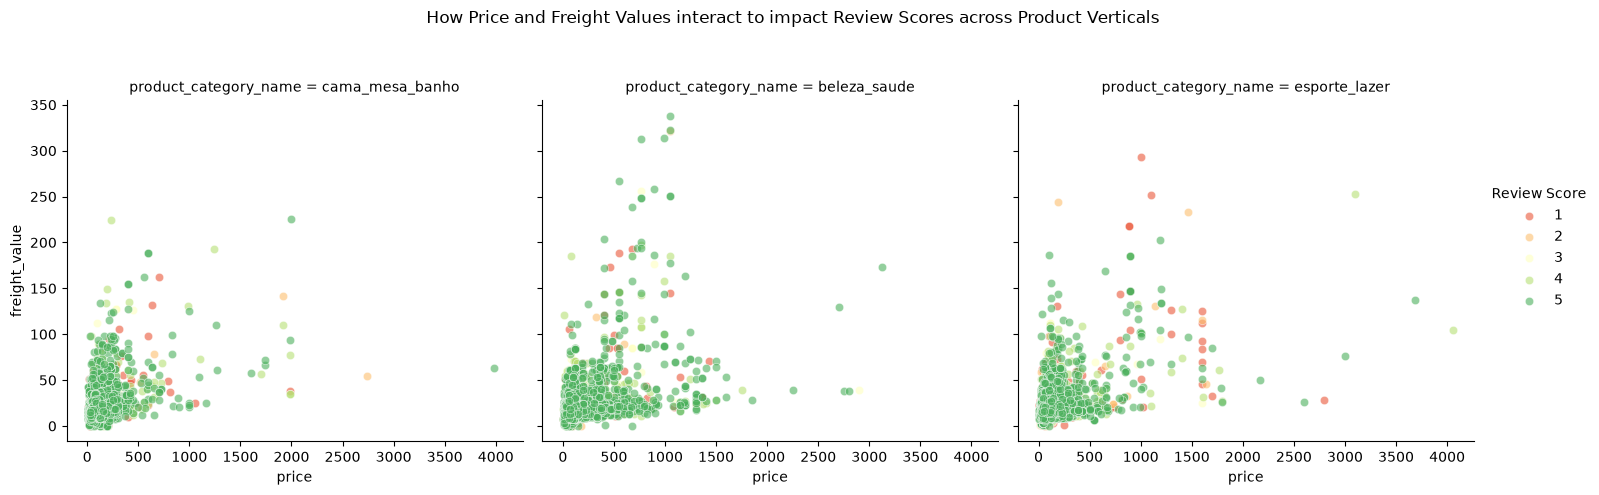

In [52]:
# 1. Filter dataset down to the top 3 most popular product categories to avoid clutter
top_categories = final_master_df['product_category_name'].value_counts().nlargest(3).index
filtered_df = final_master_df[final_master_df['product_category_name'].isin(top_categories)]

# 2. Build a multivariate facet plot
g = sns.FacetGrid(filtered_df, col="product_category_name", hue="review_score", palette="RdYlGn", height=5)
g.map(sns.scatterplot, "price", "freight_value", alpha=0.6)
g.add_legend(title="Review Score")

plt.subplots_adjust(top=0.8)
g.fig.suptitle('How Price and Freight Values interact to impact Review Scores across Product Verticals')
plt.show()